In [23]:
import numpy as np
import pandas as pd

from viral_variant_comp.simulate_count_data import create_count_data
from viral_variant_comp.plotting import plot_confidence_intervals_deviation, plot_heatmap
from viral_variant_comp.estimate import calculate_cooccurence
from viral_variant_comp.evaluate import evaluate_result
from viral_variant_comp.estimate import BFGSCompositionEstimator, StepwiseBFGSCompositionEstimator

from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [3]:
n_variants = 50
n_days = 1000
n_samples = 1000

delta_gr_range = 0.2
s_0 = 0.
o_0 = 0.
rate = 1/14  # per day, on average one new variant every two weeks
freq_entering_variants = 0.0001

data = create_count_data(n_variants = n_variants, n_days = n_days, delta_gr_range = delta_gr_range, new_var_rate = rate, freq_entering_variants = freq_entering_variants, n_samples = n_samples, s_0 = s_0, o_0 = o_0, reorder=True) #data reordered from start


#np.savez('data/count_data.npz', **data)
# to reload: np.load('data/count_data.npz')

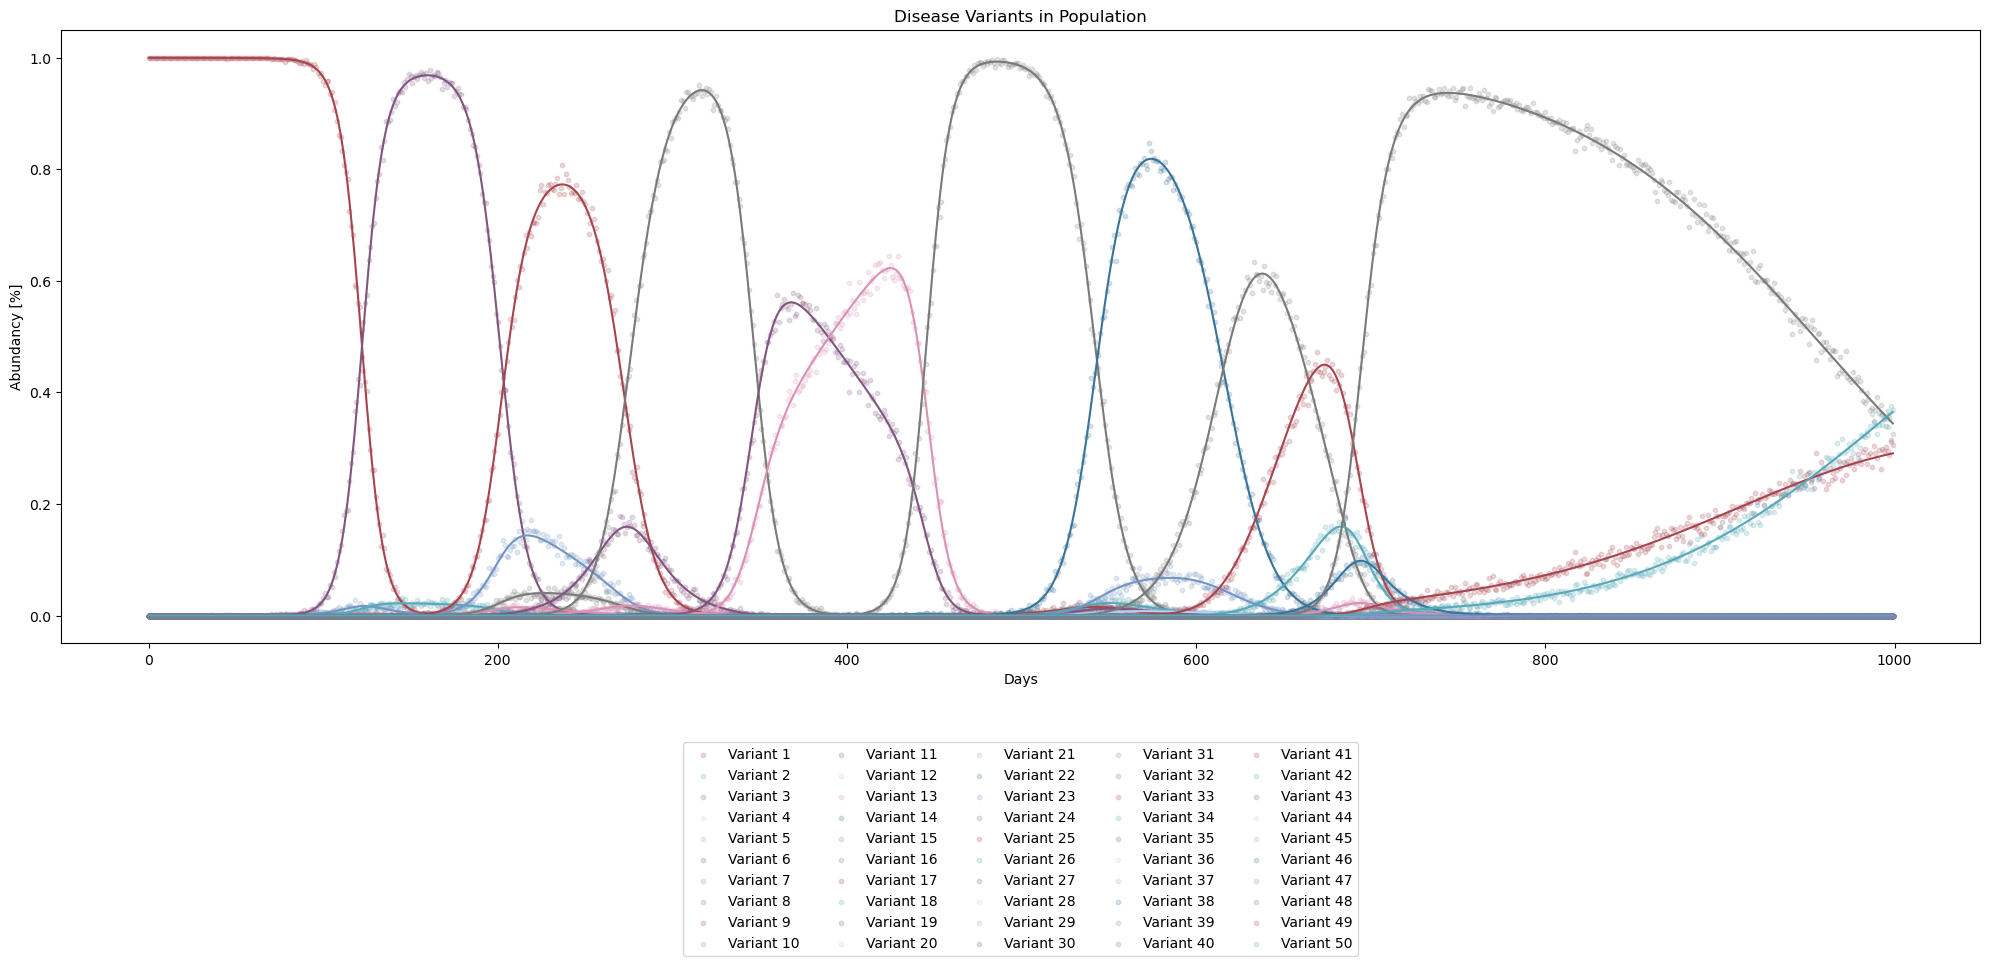

In [8]:
plot_viral_composition(data['counts'], data['freq'], y_range = (1e-5, 2), logscale=False)


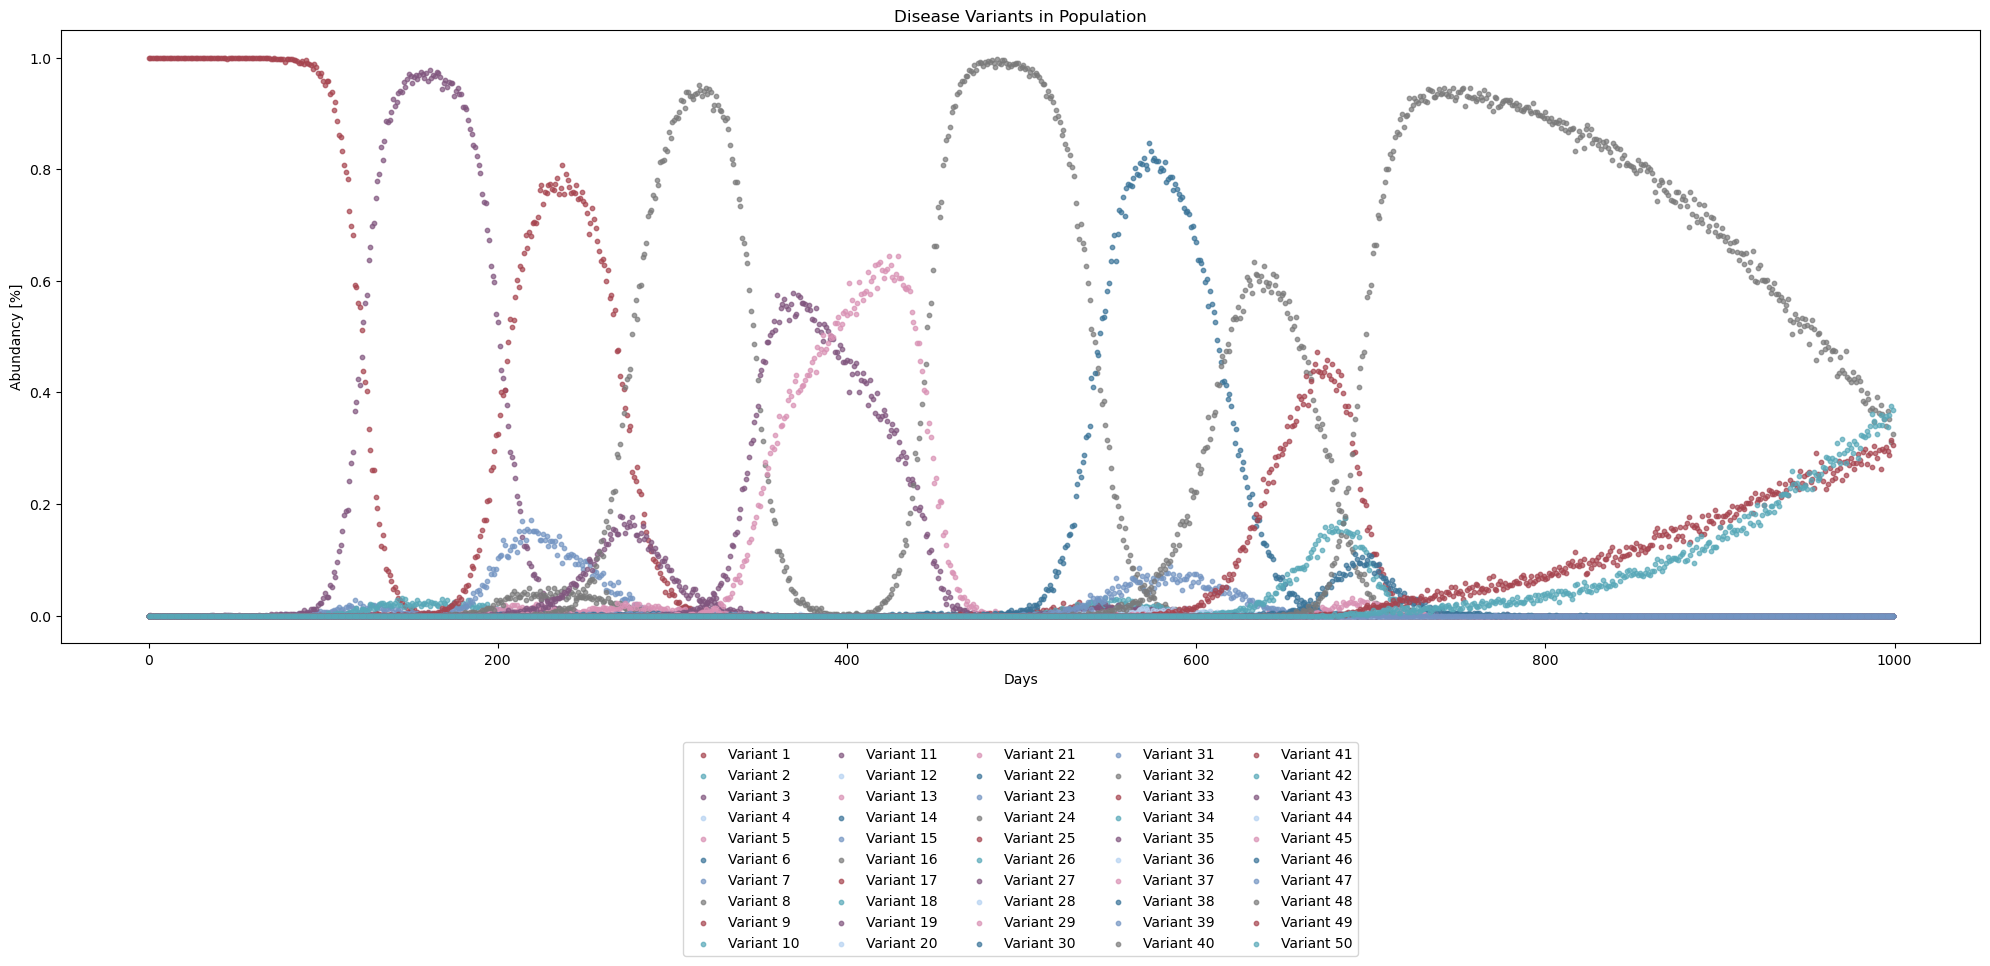

In [13]:
def plot_viral_composition_dual(counts, freq=None, composition_estimate=None,
                                 var_names=None, y_range=(1e-5, 2),
                                 show_legend=True, start_date=None):

    base_colors = [
        "#a6444f",  # reddish
        "#57a8b8",  # teal
        "#80557e",  # purple
        "#b5d2f2",  # light blue
        "#d991b4",  # pink
        "#397398",  # dark blue
        "#7394c2",  # mid blue
        "#7a7a7a"   # gray
    ]
    brighter_colors = [
        "#6baed6", "#ffae6b", "#66c266", "#ff6666", "#c2a5e2",
        "#b38f87", "#f7a6d8", "#bfbfbf", "#d4e157", "#66ddee"
    ]

    n_samples = np.sum(counts, axis=1)
    rel_abund = counts / n_samples[:, np.newaxis]
    days = np.arange(counts.shape[0])

    if var_names is None:
        var_names = [f'Variant {i+1}' for i in range(counts.shape[1])]

    # Create time labels
    if start_date is not None:
        time_labels = [datetime.strptime(start_date, "%Y-%m-%d") + timedelta(days=int(day)) for day in days]
    else:
        time_labels = days

    fig, axes = plt.subplots(2, 1, figsize=(counts.shape[0] // 50 + 4, 10), sharex=True)

    for ax_idx, logscale in enumerate([False, True]):
        ax = axes[ax_idx]

        for i in range(counts.shape[1]):
            ax.scatter(time_labels, rel_abund[:, i], s=10, alpha=0.2,
                       label=var_names[i], color=base_colors[i % 8])
            if freq is not None:
                ax.plot(time_labels, freq[:, i], color=base_colors[i % 8])
            if composition_estimate is not None:
                ax.plot(time_labels, composition_estimate[:, i],
                        color=brighter_colors[i % 10], linestyle='--')

        ax.set_ylabel("Abundancy [%]")
        if logscale:
            ax.set_yscale('log')
            ax.set_ylim(y_range)
            ax.set_title("Disease Variants in Population (log scale)")
        else:
            ax.set_title("Disease Variants in Population (linear scale)")

        ax.grid(True)

    axes[-1].set_xlabel("Date" if start_date else "Days")

    # Format x-axis with ticks every 3 months if dates are used
    if start_date:
        axes[-1].xaxis.set_major_locator(MonthLocator(interval=3))
        axes[-1].xaxis.set_major_formatter(DateFormatter('%b %Y'))
        fig.autofmt_xdate()

    if show_legend:
        if counts.shape[1] > 10:
            axes[-1].legend(ncol=counts.shape[1] // 10, loc='upper center', bbox_to_anchor=(0.5, -0.25))
        else:
            axes[-1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25))

    plt.tight_layout()
    plt.show()

In [24]:
def plot_viral_composition(counts, freq = None, composition_estimate = None, var_names = None, y_range = (1e-5, 2), logscale = True, start_date= None):

    plt.figure(figsize=(counts.shape[0] // 50, 10))
    
    base_colors = [
        "#a6444f",  # reddish
        "#57a8b8",  # teal
        "#80557e",  # purple
        "#b5d2f2",  # light blue
        "#d991b4",  # pink
        "#397398",  # dark blue
        "#7394c2",  # mid blue
        "#7a7a7a"   # gray
    ]


    brighter_colors = [
    "#6baed6",  # lighter blue
    "#ffae6b",  # lighter orange
    "#66c266",  # lighter green
    "#ff6666",  # lighter red
    "#c2a5e2",  # lighter purple
    "#b38f87",  # lighter brown
    "#f7a6d8",  # lighter pink
    "#bfbfbf",  # lighter gray
    "#d4e157",  # lighter olive
    "#66ddee"   # lighter cyan
    ]

    n_samples = np.sum(counts, axis = 1)
    rel_abund = counts / n_samples[:, np.newaxis]

    if var_names is None:
        var_names = [f'Variant {i+1}' for i in range(counts.shape[1])]

    # Create time labels
    if start_date is not None:
        time_labels = [datetime.strptime(start_date, "%Y-%m-%d") + timedelta(days=int(day)) for day in days]
    else:
        time_labels = np.arange(counts.shape[0])

    for i in range(counts.shape[1]):

        plt.scatter(time_labels, rel_abund[:, i], s= 10, alpha = 0.7, label = var_names[i], color = base_colors[i % 8])
        if freq is not None:
            plt.plot(time_labels, freq[:, i], color = base_colors[i % 8])
        if composition_estimate is not None:
            plt.plot(time_labels, composition_estimate[:, i], color = brighter_colors[i % 10], linestyle='--')

    plt.xlabel("Date" if isinstance(time_labels[0], datetime) else "Days")
    plt.ylabel("Abundancy [%]")
    if(logscale):
        plt.yscale('log')
        plt.ylim(y_range)
    plt.title("Disease Variants in Population")

    if isinstance(time_labels[0], datetime):
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))



    if(counts.shape[1] > 10):
        plt.legend(ncol = counts.shape[1] // 10, loc='upper center', bbox_to_anchor=(0.5, -0.15))
    else:
        plt.legend()
    plt.grid(False)
    plt.tight_layout()
    #plt.savefig("figures/variant_comp.pdf", dpi=1000, bbox_inches='tight')
    plt.show()




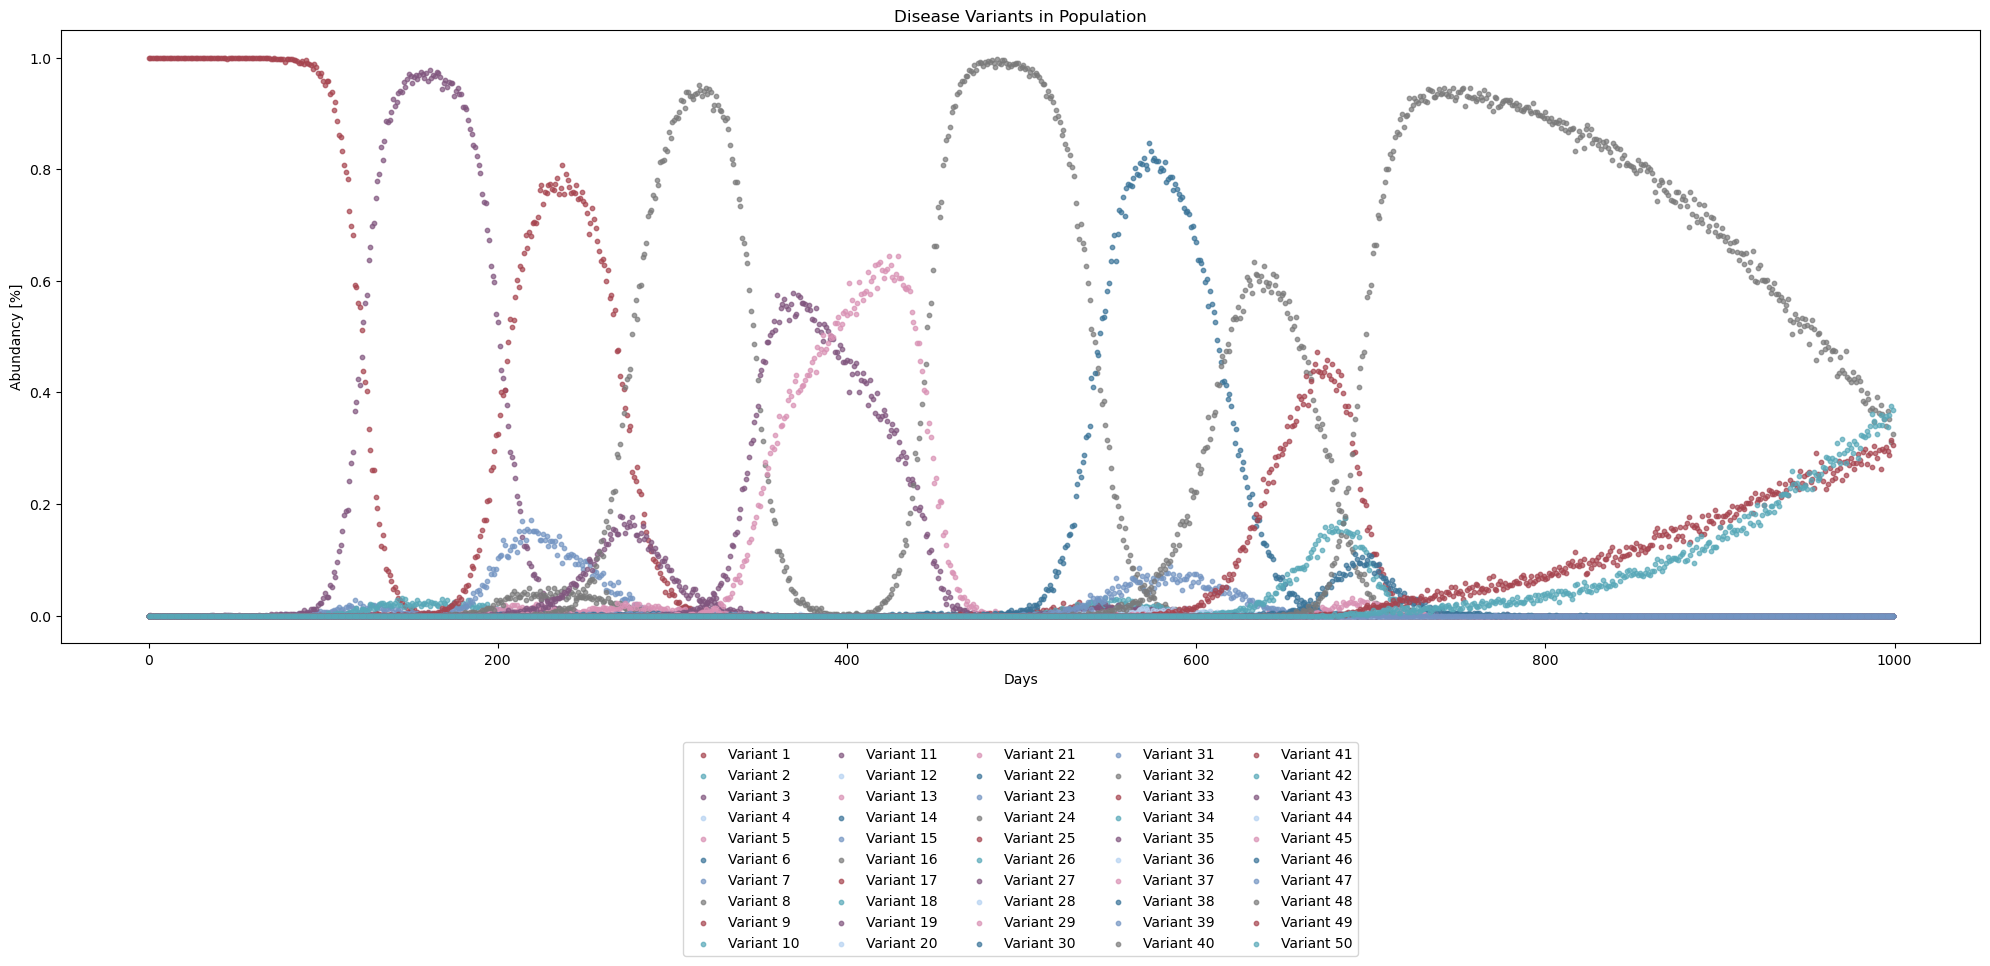

In [25]:
plot_viral_composition(data['counts'], y_range = (1e-5, 2), logscale=False)